Biomedical GNN demo (breast cancer dataset)

This notebook loads the scikit-learn breast cancer dataset, builds a sample similarity k-NN graph, trains a small GCN for node classification, saves the processed CSV, and visualizes results.

Saved processed CSV to data/breast_cancer.csv
Epoch 10 loss=0.6518 train_acc=0.521 test_acc=0.517
Epoch 20 loss=0.5456 train_acc=0.929 test_acc=0.950
Epoch 30 loss=0.4500 train_acc=0.950 test_acc=0.983
Epoch 40 loss=0.3675 train_acc=0.929 test_acc=0.950
Epoch 50 loss=0.3013 train_acc=0.921 test_acc=0.950
Final test acc: 0.949999988079071


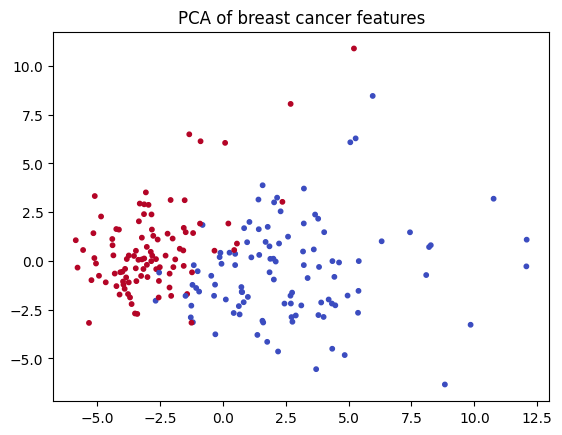

In [3]:
# Cell 1: setup imports and path
import sys, os

def find_project_root():
    p = os.getcwd()
    while True:
        if os.path.exists(os.path.join(p, 'src')) and os.path.isdir(os.path.join(p, 'src')):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return os.getcwd()
        p = parent

proj_root = find_project_root()
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Subsample for demo
max_samples = 200
if X.shape[0] > max_samples:
    X = X[:max_samples]
    y = y[:max_samples]

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

# Save CSV
os.makedirs(os.path.join(proj_root,'data'), exist_ok=True)
pd.DataFrame(Xs).to_csv(os.path.join(proj_root,'data','breast_cancer.csv'), index=False)
print('Saved processed CSV to data/breast_cancer.csv')

# k-NN graph
A = kneighbors_graph(Xs, n_neighbors=10, mode='connectivity', include_self=True).toarray().astype(float)
deg = A.sum(axis=1, keepdims=True)
deg[deg==0]=1
A_norm = A/deg

Xt = torch.tensor(Xs, dtype=torch.float32)
At = torch.tensor(A_norm, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.long)

# Simple model
class SimpleNodeGCN(nn.Module):
    def __init__(self, in_feats, hidden, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_feats, hidden)
        self.fc2 = nn.Linear(hidden, num_classes)
    def forward(self, x, adj):
        h = torch.matmul(adj, x)
        h = torch.relu(self.fc1(h))
        h = torch.matmul(adj, h)
        logits = self.fc2(h)
        return logits

model = SimpleNodeGCN(in_feats=Xt.shape[1], hidden=32, num_classes=2)
opt = optim.Adam(model.parameters(), lr=1e-3)

indices = list(range(Xt.shape[0]))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=y)
train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor(test_idx, dtype=torch.long)

for epoch in range(50):
    model.train()
    logits = model(Xt, At)
    loss = nn.CrossEntropyLoss()(logits[train_idx], yt[train_idx])
    opt.zero_grad(); loss.backward(); opt.step()
    if (epoch+1)%10==0:
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            acc_train = (preds[train_idx]==yt[train_idx]).float().mean().item()
            acc_test = (preds[test_idx]==yt[test_idx]).float().mean().item()
        print(f'Epoch {epoch+1} loss={loss.item():.4f} train_acc={acc_train:.3f} test_acc={acc_test:.3f}')

# final
with torch.no_grad():
    logits = model(Xt, At)
    preds = logits.argmax(dim=1)
    acc_test = (preds[test_idx]==yt[test_idx]).float().mean().item()
print('Final test acc:', acc_test)

# visualize PCA projection colored by label
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Z = pca.fit_transform(Xs)
plt.scatter(Z[:,0], Z[:,1], c=y, cmap='coolwarm', s=10)
plt.title('PCA of breast cancer features')
plt.show()

### Visualization explanation: PCA projection

The PCA scatter plots samples projected onto the first two principal components. Each point is a patient/sample; color indicates the label (malignant vs benign).

Interpretation: If classes separate into distinct clusters, the features capture discriminative structure; overlap implies the classifier must rely on higher-dimensional structure or graph relations.

Notes

- This demo uses a standard biomedical dataset and demonstrates how GNNs can be applied to patient/sample graphs.
- For true RNA-seq or ATAC-seq analyses, replace the dataset-loading cell with GEO download and single-cell preprocessing.

Label counts: [104  96]


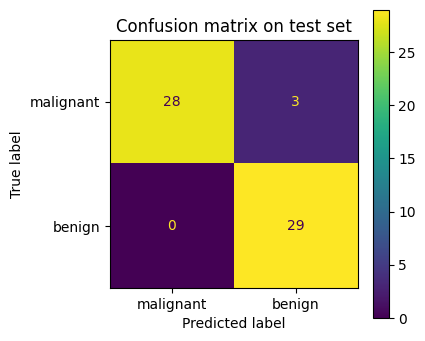


Classification report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        31
           1       0.91      1.00      0.95        29

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [4]:
# Cell (Data exploration & evaluation): show label balance, confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

with torch.no_grad():
    logits = model(Xt, At)
    preds = logits.argmax(dim=1).numpy()

print('Label counts:', np.bincount(y))

from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y[test_idx.numpy()], preds[test_idx.numpy()])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant','benign'])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax)
plt.title('Confusion matrix on test set')
plt.show()

print('\nClassification report:\n', classification_report(y[test_idx.numpy()], preds[test_idx.numpy()]))

Description (Biomedical GNN, linkage to QAOA)

- Problem & impact: Improving computational methods for biomedical data analysis (e.g., diagnostic feature classification, single-cell analysis) accelerates healthcare research, diagnostics, and drug discovery — activities of clear national importance.
- Contribution: This demo shows how graph-based ML methods (GNNs) translate structured biomedical data (sample similarity graphs) into reliable predictions. When combined with QAOA-style quantum heuristics for combinatorial subproblems (e.g., experimental design, feature selection), the hybrid workflow can reduce time-to-solution for large biomedical optimization problems.
- Inputs/Outputs: Input — processed biomedical feature matrix (CSV saved under `data/`); Output — per-sample class predictions and trained model weights.
- Why hybrid QAOA+GNN matters: GNNs supply structure-aware priors or compressed representations of biomedical graphs that can be used by QAOA to perform combinatorial subroutines (e.g., grouping, cohort selection) more efficiently.

